# Car Price Prediction Using Linear Regression 
## Project Overview
This project builds a Machine Learning model to predict the selling price of second-hand cars based on factors such as:
* <b>Price</b>: The Price of the car in dollars
* <b>Age</b>: The age of the car in months
* <b>KM</b>: How many KMS did the car was used
* <b>FuelType</b>: Petrol/Diesel/CNG car
* <b>HP</b>: Horse power of the car
* <b>MetColor</b>: Whether car has metallic color or not
* <b>Automatic</b>: Whether car has automatic transmission or not
* <b>CC</b>: The engine size of the car
* <b>Doors</b>: The number of doors in the car
* <b>Weight</b>: The weight of the car

The objective is to help buyers and dealerships estimate the fair price of a used vehicle scientifically instead of guessing.

## 1. Load dataset


In [3]:
# Supressing the warning messages
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Reading the dataset
import pandas as pd
import numpy as np
CarPricesData=pd.read_csv('C:/Users/sohin/OneDrive/Desktop/IVY/Python/Advanced/PythonProject/CarPricesData.csv', encoding='latin')

In [5]:
print('Shape before deleting duplicate values:', CarPricesData.shape)

# Removing duplicate rows if any
CarPricesData=CarPricesData.drop_duplicates()
print('Shape After deleting duplicate values:', CarPricesData.shape)
CarPricesData.head(10)

Shape before deleting duplicate values: (1436, 10)
Shape After deleting duplicate values: (1435, 10)


,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
0,13500,23.0,46986,Diesel,90,1,0,2000.0,3,1165.0
1,13750,23.0,72937,Diesel,90,1,0,2000.0,3,1165.0
2,13950,24.0,41711,Diesel,90,1,0,2000.0,3,1165.0
3,14950,26.0,48000,Diesel,90,0,0,2000.0,3,1165.0
4,13750,30.0,38500,Diesel,90,0,0,2000.0,3,1170.0
5,12950,32.0,61000,Diesel,90,0,0,2000.0,3,1170.0
6,16900,27.0,94612,Diesel,90,1,0,2000.0,3,1245.0
7,18600,30.0,75889,Diesel,90,1,0,2000.0,3,1245.0
8,21500,27.0,19700,Petrol,192,0,0,1800.0,3,1185.0
9,12950,23.0,71138,Diesel,69,0,0,1900.0,3,1105.0


## 2. Determining the type of ML model which can predict the Price of a second hand Car
* Target Variable: Price
* Predictors: Age, KM, FuelType, CC etc.

Based on the problem statement you can understand that we need to create a <b>supervised ML Regression model</b>, as the target variable is Continuous.

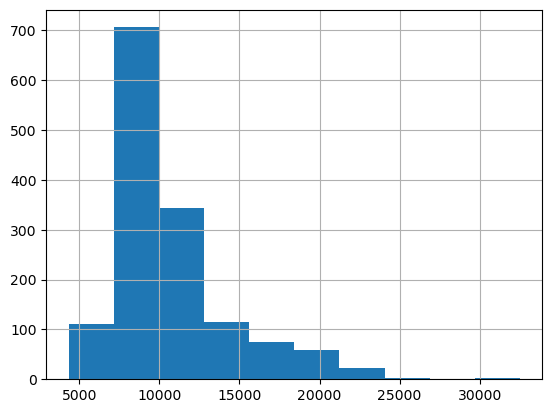

In [8]:
import matplotlib.pyplot as plt

CarPricesData['Price'].hist()
plt.show()

The data distribution of the target variable is satisfactory to proceed further. There are sufficient number of rows for each type of values to learn from. So, we can perform regression.

## 3. Basic Data Exploration

In [11]:
CarPricesData.head()

,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
0,13500,23.0,46986,Diesel,90,1,0,2000.0,3,1165.0
1,13750,23.0,72937,Diesel,90,1,0,2000.0,3,1165.0
2,13950,24.0,41711,Diesel,90,1,0,2000.0,3,1165.0
3,14950,26.0,48000,Diesel,90,0,0,2000.0,3,1165.0
4,13750,30.0,38500,Diesel,90,0,0,2000.0,3,1170.0


In [12]:
CarPricesData.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1435 entries, 0 to 1435
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Price      1435 non-null   int64  
 1   Age        1433 non-null   float64
 2   KM         1435 non-null   int64  
 3   FuelType   1431 non-null   object 
 4   HP         1435 non-null   int64  
 5   MetColor   1435 non-null   int64  
 6   Automatic  1435 non-null   int64  
 7   CC         1433 non-null   float64
 8   Doors      1435 non-null   int64  
 9   Weight     1433 non-null   float64
dtypes: float64(3), int64(6), object(1)
memory usage: 123.3+ KB


In [13]:
CarPricesData.describe(include='all')

,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
count,1435.000000,1433.000000,1435.000000,1431,1435.000000,1435.000000,1435.000000,1433.000000,1435.000000,1433.000000
unique,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Petrol,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,1260,NaN,NaN,NaN,NaN,NaN,NaN
mean,10720.915679,56.020237,68571.782578,NaN,101.491986,0.674564,0.055749,1566.688765,4.032753,1072.314724
std,3608.732978,18.544948,37491.094553,NaN,14.981408,0.468701,0.229517,186.893360,0.952667,52.283038
min,4350.000000,1.000000,1.000000,NaN,69.000000,0.000000,0.000000,1300.000000,2.000000,1000.000000
25%,8450.000000,44.000000,43000.000000,NaN,90.000000,0.000000,0.000000,1400.000000,3.000000,1040.000000
50%,9900.000000,61.000000,63451.000000,NaN,110.000000,1.000000,0.000000,1600.000000,4.000000,1070.000000
75%,11950.000000,70.000000,87041.500000,NaN,110.000000,1.000000,0.000000,1600.000000,5.000000,1085.000000


In [14]:
CarPricesData.nunique()

Price         236
Age            77
KM           1263
FuelType        3
HP             12
MetColor        2
Automatic       2
CC             12
Doors           4
Weight         59
dtype: int64

### Basic Data Exploration Results
Based on the basic exploration above, we can now create a simple initial roadmap for further analysis. 
The selected columns in this step are not final, further study will be done and then a final list will be created

* <b>Price</b>: Continuous. Selected. This is the <b>Target Variable!</b>
* <b>Age</b>: Continuous. Selected.
* <b>KM</b>: Continuous. Selected.
* <b>FuelType</b>: Categorical. Selected.
* <b>HP</b>: Categorical. Selected.
* <b>MetColor</b>: Categorical. Selected.
* <b>Automatic</b>: Categorical. Selected.
* <b>CC</b>: Categorical. Selected.
* <b>Doors</b>: Categorical. Selected.
* <b>Weight</b>: Continuous. Selected.

## 4. Visual Exploratory Data Analysis

### a. Visual Exploratory Data Analysis


In [18]:
def PlotBarCharts(inpData, colsToPlot):
    %matplotlib inline
    
    import matplotlib.pyplot as plt
    
    # Generating multiple subplots
    fig, subPlot=plt.subplots(nrows=1, ncols=len(colsToPlot), figsize=(20,5))
    fig.suptitle('Bar charts of: '+ str(colsToPlot))

    for colName, plotNumber in zip(colsToPlot, range(len(colsToPlot))):
        inpData.groupby(colName).size().plot(kind='bar',ax=subPlot[plotNumber])
    plt.show()

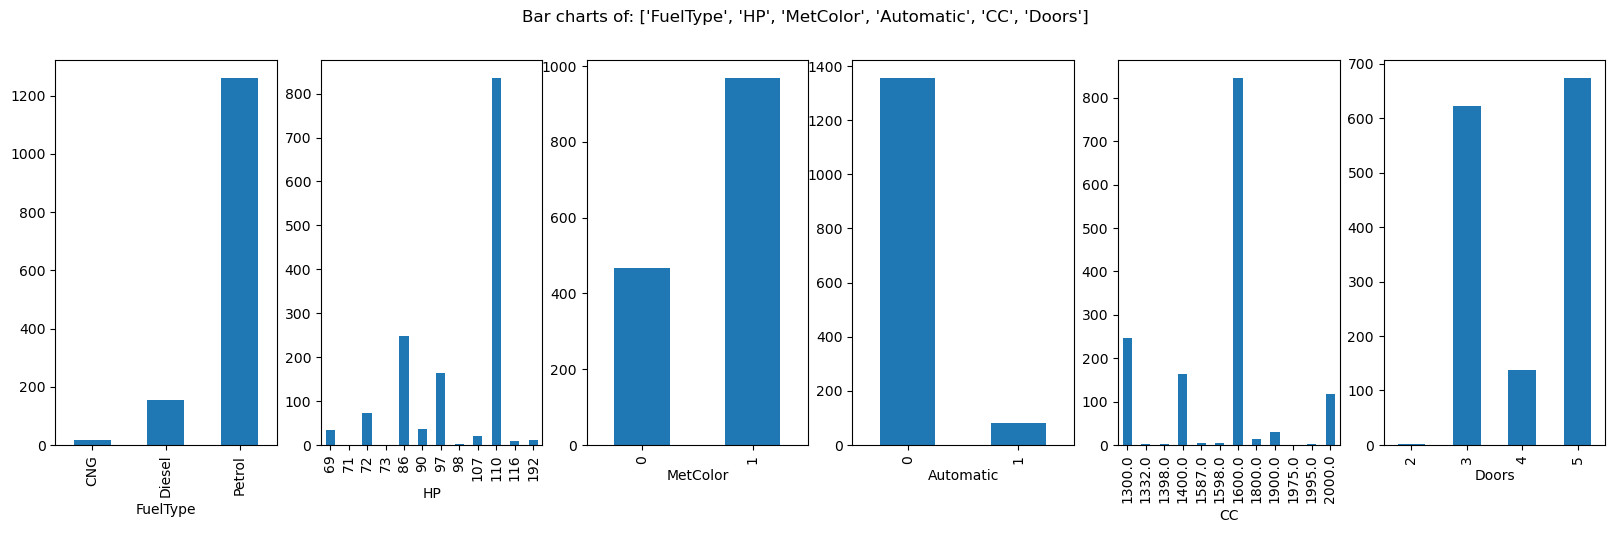

In [19]:
PlotBarCharts(inpData=CarPricesData, colsToPlot=['FuelType', 'HP', 'MetColor', 
                                                 'Automatic', 'CC', 'Doors'])

#### Bar Charts Interpretation
In the ideal bar chart each category has comparable frequency. Hence, there are enough rows for each category in the data for the ML algorithm to learn.

<b>Selected Categorical Variables</b>: All the categorical variables are selected for further analysis.

'FuelType', 'HP', 'MetColor', 'Automatic', 'CC', 'Doors'

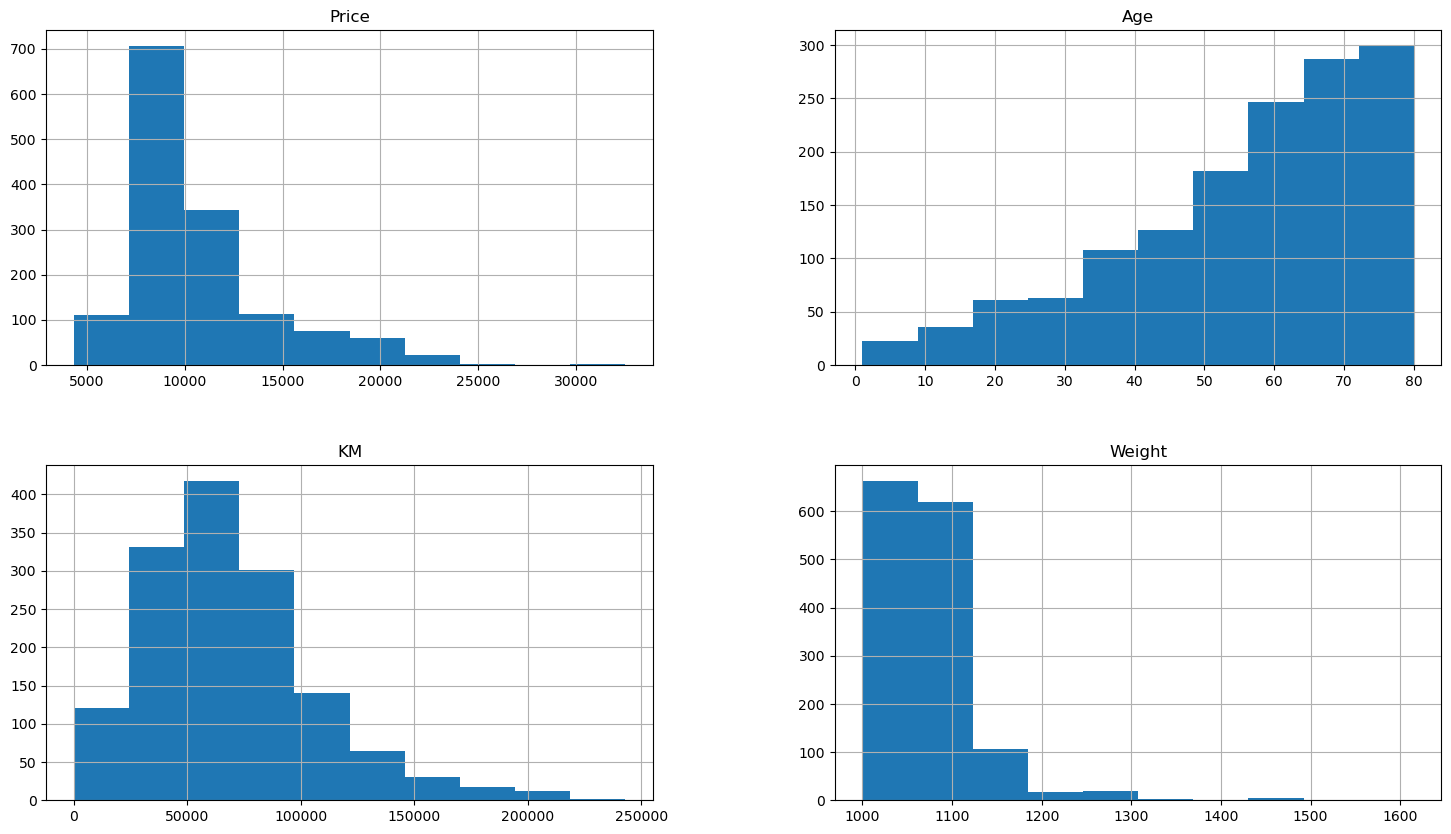

In [21]:
import matplotlib.pyplot as plt

CarPricesData.hist(column=['Price', 'Age', 'KM', 'Weight'],figsize=(18, 10),layout=(2, 2) )
plt.show()

#### Histogram Interpretation
The ideal outcome for histogram is a bell curve or slightly skewed bell curve. 

<b>Selected Continuous Variables:</b>
* <b>Price</b> : Selected. The distribution is good. Outliers are seen near 30000, need to treat them
* <b>KM</b>: Selected. The distribution is good.
* <b>Age</b>: Selected. The distribution is good.
* <b>Weight</b>: Selected. The distribution is good. Outliers are seen beyond 1400, need to treat them.

### b. Outlier treatment

#### i. Treating outliers for 'Weight' column

In [25]:
# Counting the number of rows having outliers
len(CarPricesData['Weight'][CarPricesData['Weight']>1400])

5

In [26]:
# Finding logical value near 1400
CarPricesData['Weight'][CarPricesData['Weight']<1400].sort_values(ascending=False)

112     1320.0
138     1320.0
115     1280.0
119     1275.0
68      1275.0
         ...  
927     1000.0
1410    1000.0
605     1000.0
1021    1000.0
957     1000.0
Name: Weight, Length: 1428, dtype: float64

Based on the above output, the nearest logical value is 1320, hence, replacing any value greater than 1400 with it.

In [28]:
# Replacing outliers with nearest logical value
CarPricesData['Weight'][CarPricesData['Weight']>1400]=1320

#### ii. Treating outliers for Price column

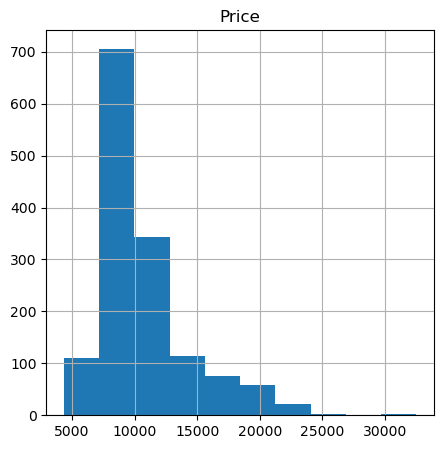

In [30]:
CarPricesData.hist(['Price'], figsize=(5,5));
plt.show()

In [31]:
CarPricesData['Price'][CarPricesData['Price']<29000].sort_values(ascending=False)

115     24990
112     24950
147     24500
141     23950
171     23750
        ...  
402      5150
192      4750
393      4450
1048     4400
191      4350
Name: Price, Length: 1432, dtype: int64

In [32]:
CarPricesData['Price'][CarPricesData['Price']>29000]=24990

### Visualizing the distribution again after outlier treatment

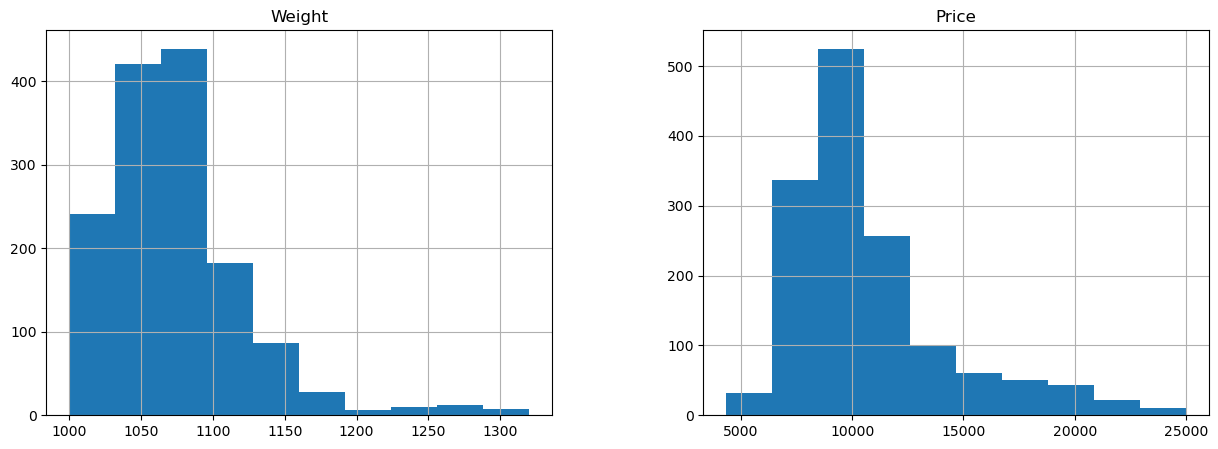

In [34]:
# Histogram for weight after outlier treatment
CarPricesData[['Weight', 'Price']].hist(figsize=(15,5));
plt.show()

The distribution has improved after the outlier treatment. There is still a tail on the right side, but it is thick, hence it is acceptable.

### c. Missing values treatment

Price        0
Age          2
KM           0
FuelType     4
HP           0
MetColor     0
Automatic    0
CC           2
Doors        0
Weight       2
dtype: int64


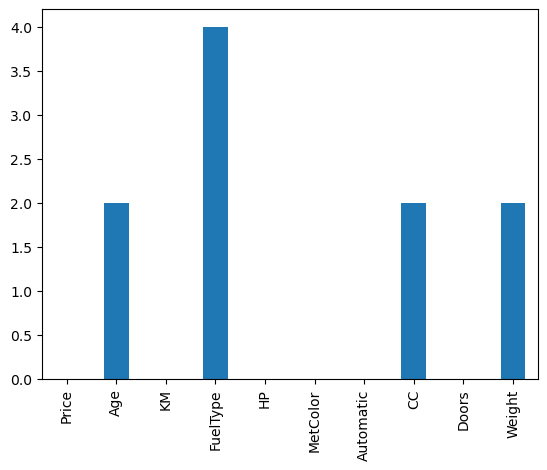

In [37]:
# Finding how many missing values are there for each column
print(CarPricesData.isnull().sum())
CarPricesData.isnull().sum().plot(kind='bar') 
plt.show()

Treating missing values with Median for Continuous values and Mode for categorical values.

In [39]:
CarPricesData['FuelType'].mode()[0]

'Petrol'

In [40]:
CarPricesData['Weight'].median()

1070.0

In [41]:
CarPricesData['Age'].median()

61.0

In [42]:
# Treating missing values of categorical variable with MODE value
CarPricesData['FuelType'].fillna(value=CarPricesData['FuelType'].mode()[0], inplace=True)
CarPricesData['CC'].fillna(value=CarPricesData['CC'].mode()[0], inplace=True)

In [43]:
# Treating missing values of continuous variable with Median value
CarPricesData['Weight'].fillna(value=CarPricesData['Weight'].median(), inplace=True)
CarPricesData['Age'].fillna(value=CarPricesData['Age'].median(), inplace=True)

In [44]:
# Checking missing values again after the treatment
CarPricesData.isnull().sum()

Price        0
Age          0
KM           0
FuelType     0
HP           0
MetColor     0
Automatic    0
CC           0
Doors        0
Weight       0
dtype: int64

## 5. Feature Selection (Bi-Variate analysis)
Now its time to finally choose the best columns(Features) which are correlated to the Target variable.
This can be done directly by measuring the correlation values or ANOVA/Chi-Square tests. However, it is always helpful to visualize the relation between the Target variable and each of the predictors to get a better sense of data.

### a. Relationship exploration: Continuous Vs Continuous -- Scatter Charts

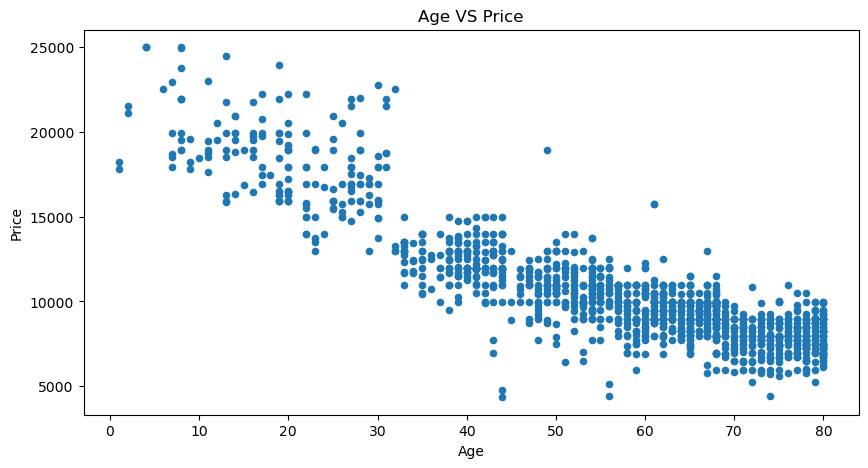

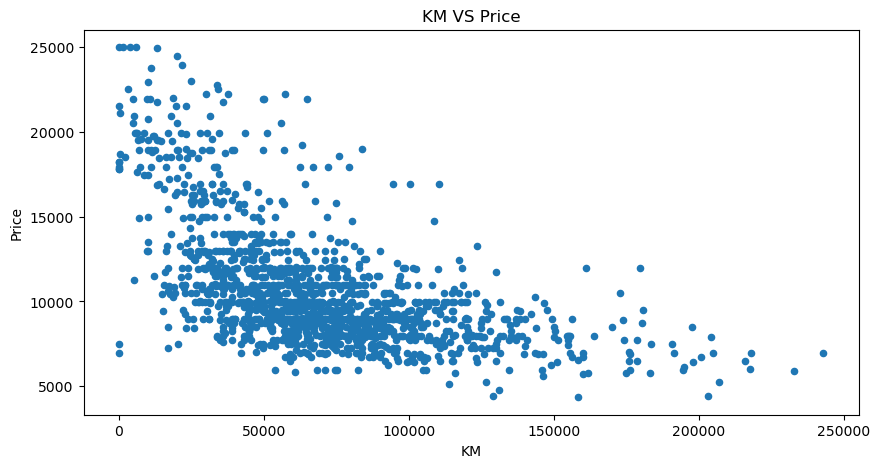

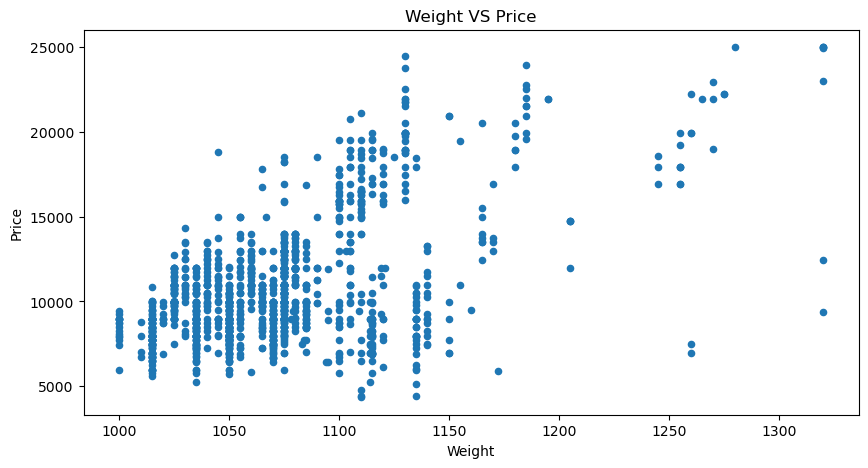

In [47]:
import matplotlib.pyplot as plt

ContinuousCols = ['Age', 'KM', 'Weight']

for predictor in ContinuousCols:
    ax = CarPricesData.plot.scatter(x=predictor,y='Price',figsize=(10, 5),title=predictor + " VS " + 'Price')
    plt.show()

#### Statistical Feature Selection (Continuous Vs Continuous) using Correlation value

In [49]:
ContinuousCols=['Price','Age','KM','Weight']

# Creating the correlation matrix
CorrelationData=CarPricesData[ContinuousCols].corr()
CorrelationData

,Price,Age,KM,Weight
Price,1.000000,-0.880043,-0.573402,0.580007
Age,-0.880043,1.000000,0.502604,-0.488324
KM,-0.573402,0.502604,1.000000,-0.013607
Weight,0.580007,-0.488324,-0.013607,1.000000


In [50]:
# Filtering only those columns where absolute correlation > 0.5 with Target Variable
CorrelationData['Price'][abs(CorrelationData['Price']) > 0.5]

Price     1.000000
Age      -0.880043
KM       -0.573402
Weight    0.580007
Name: Price, dtype: float64

<b>Final selected Continuous columns:</b>

'Age','KM','Weight'

In [52]:
abs(CorrelationData['Price'])>0.5

Price     True
Age       True
KM        True
Weight    True
Name: Price, dtype: bool

### b. Relationship exploration: Categorical Vs Continuous -- Box Plots
When the target variable is Continuous and the predictor variable is Categorical we analyze the relation using Boxplots and measure the strength of relation using Anova test

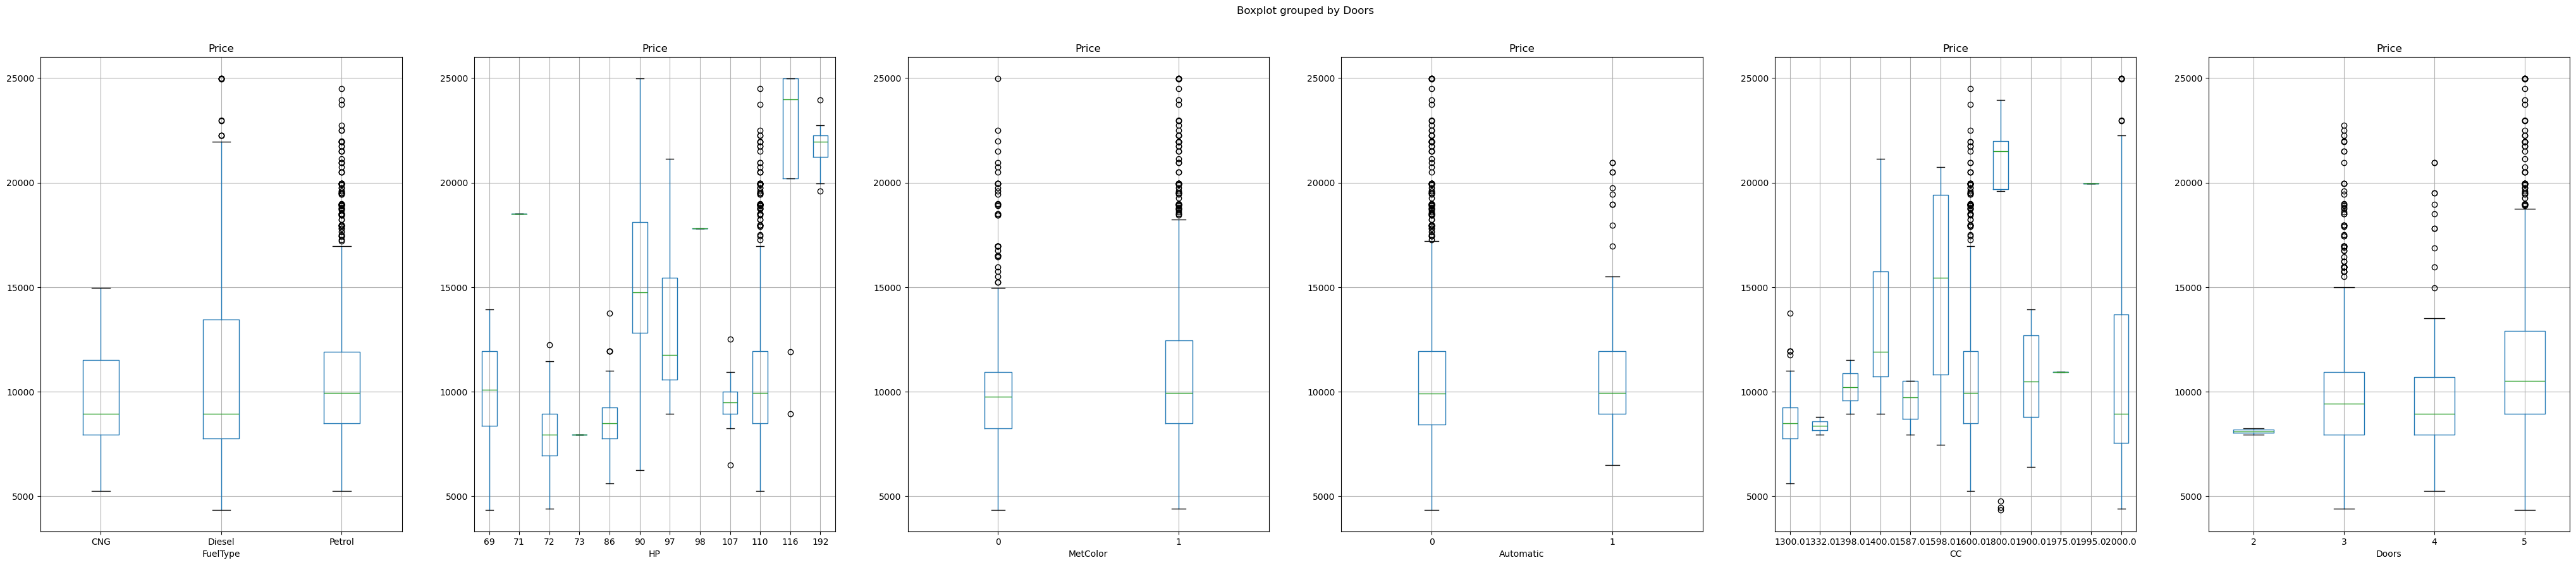

In [54]:
CategoricalColsList=['FuelType', 'HP', 'MetColor', 'Automatic', 'CC', 'Doors']

import matplotlib.pyplot as plt
fig, PlotCanvas=plt.subplots(nrows=1, ncols=len(CategoricalColsList), figsize=(50,10))

for PredictorCol , i in zip(CategoricalColsList, range(len(CategoricalColsList))):
    ax=CarPricesData.boxplot(column='Price', by=PredictorCol, figsize=(5,5), vert=True, ax=PlotCanvas[i])
plt.show()

#### Box-Plots interpretation
In this data, all the categorical predictors looks correlated with the Target variable except "Fueltype","Automatic" and "MetColor" they seems like a border cases, as the boxes are close to each other.

We confirm this by looking at the results of ANOVA test below

#### Statistical Feature Selection (Categorical Vs Continuous) using ANOVA test

In [57]:
CategoryGroupLists=CarPricesData.groupby('FuelType')['Price'].apply(list)
CategoryGroupLists

FuelType
CNG       [7750, 11950, 11950, 14950, 12950, 8500, 9250,...
Diesel    [13500, 13750, 13950, 14950, 13750, 12950, 169...
Petrol    [21500, 20950, 19950, 19600, 21500, 22500, 220...
Name: Price, dtype: object

In [58]:
# Defining a function to find the statistical relationship with all the categorical variables
def FunctionAnova(inpData, TargetVariable, CategoricalPredictorList):
    from scipy.stats import f_oneway

    # Creating an empty list of final selected predictors
    SelectedPredictors=[]
    
    print('##### ANOVA Results ##### \n')
    for predictor in CategoricalPredictorList:
        CategoryGroupLists=inpData.groupby(predictor)[TargetVariable].apply(list)
        AnovaResults = f_oneway(*CategoryGroupLists)
        #print(AnovaResults)
        
        # If the ANOVA P-Value is <0.05, that means we reject H0
        if (AnovaResults[1] < 0.05):
            print(predictor, 'is correlated with', TargetVariable, '| P-Value:', AnovaResults[1])
            SelectedPredictors.append(predictor)
        else:
            # Accepting the H0 if the P value is more than 0.05
            print(predictor, 'is NOT correlated with', TargetVariable, '| P-Value:', AnovaResults[1])
    
    return(SelectedPredictors)

In [59]:
# Calling the function to check which categorical variables are correlated with target
CategoricalPredictorList=['FuelType', 'HP', 'MetColor', 'Automatic', 'CC', 'Doors']
FunctionAnova(inpData=CarPricesData, 
              TargetVariable='Price', 
              CategoricalPredictorList=CategoricalPredictorList)

##### ANOVA Results ##### 

FuelType is NOT correlated with Price | P-Value: 0.13509668858708382
HP is correlated with Price | P-Value: 1.9274014078136855e-103
MetColor is correlated with Price | P-Value: 2.9082820205816128e-05
Automatic is NOT correlated with Price | P-Value: 0.17860614078485976
CC is correlated with Price | P-Value: 4.667580175740994e-49
Doors is correlated with Price | P-Value: 1.0200265373934503e-12


['HP', 'MetColor', 'CC', 'Doors']

The results of ANOVA confirm our visual analysis using box plots above.

All categorical variables are correlated with the Target variable except "FuelType" and "Automatic". 

<b>Final selected Categorical columns:</b>

'HP', 'MetColor', 'CC', 'Doors'

### Selecting final predictors for Machine Learning
Based on the above tests, selecting the final columns for machine learning

In [62]:
SelectedColumns=['Age','KM','Weight','HP', 'MetColor', 'CC', 'Doors','FuelType']

# Selecting final columns
DataForML=CarPricesData[SelectedColumns]

## 6. Data Pre-processing for Machine Learning

In [64]:
# Treating all the nominal variables at once using dummy variables
DataForML_Numeric=pd.get_dummies(DataForML)

# Adding Target Variable to the data
DataForML_Numeric['Price']=CarPricesData['Price']

DataForML_Numeric.head(20)

,Age,KM,Weight,HP,MetColor,CC,Doors,FuelType_CNG,FuelType_Diesel,FuelType_Petrol,Price
0,23.0,46986,1165.0,90,1,2000.0,3,False,True,False,13500
1,23.0,72937,1165.0,90,1,2000.0,3,False,True,False,13750
2,24.0,41711,1165.0,90,1,2000.0,3,False,True,False,13950
3,26.0,48000,1165.0,90,0,2000.0,3,False,True,False,14950
4,30.0,38500,1170.0,90,0,2000.0,3,False,True,False,13750
5,32.0,61000,1170.0,90,0,2000.0,3,False,True,False,12950
6,27.0,94612,1245.0,90,1,2000.0,3,False,True,False,16900
7,30.0,75889,1245.0,90,1,2000.0,3,False,True,False,18600
8,27.0,19700,1185.0,192,0,1800.0,3,False,False,True,21500
9,23.0,71138,1105.0,69,0,1900.0,3,False,True,False,12950


## 7. Machine Learning: Splitting the data into Training and Testing sample

In [66]:
# Separate Target Variable and Predictor Variables
TargetVariable='Price'
Predictors=['Age', 'KM', 'Weight', 'HP', 'MetColor', 'CC', 'Doors']

X=DataForML_Numeric[Predictors].values
y=DataForML_Numeric[TargetVariable].values

# Split the data into training and testing set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=31)

# Quick check on the shapes of train and test
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1004, 7)
(1004,)
(431, 7)
(431,)


## 8. Multiple Linear Regression

In [68]:
# Multiple Linear Regression
from sklearn.linear_model import LinearRegression
RegModel = LinearRegression()


# Creating the model on Training Data
LREG=RegModel.fit(X_train,y_train) 


from sklearn import metrics
# Measuring Goodness of fit in Training data
print('R2 Value:',metrics.r2_score(y_train, LREG.predict(X_train))) 


print('\n##### Model Validation and Accuracy Calculations ##########')

# Printing some sample values of prediction
prediction=LREG.predict(X_test)
TestingDataResults=pd.DataFrame(data=X_test, columns=Predictors)
TestingDataResults[TargetVariable]=y_test
TestingDataResults[('Predicted'+TargetVariable)]=np.round(prediction)

TestingDataResults


R2 Value: 0.8771946155052472

##### Model Validation and Accuracy Calculations ##########


,Age,KM,Weight,HP,MetColor,CC,Doors,Price,PredictedPrice
0,27.0,32809.0,1110.0,97.0,1.0,1400.0,5.0,17950,15979.0
1,62.0,88667.0,1040.0,110.0,1.0,1600.0,4.0,7900,9044.0
2,74.0,84123.0,1050.0,110.0,0.0,1600.0,3.0,7950,7966.0
3,80.0,57787.0,1015.0,86.0,0.0,1300.0,3.0,8250,6686.0
4,56.0,62751.0,1050.0,110.0,0.0,1600.0,3.0,9900,10411.0
...,...,...,...,...,...,...,...,...,...
426,40.0,161000.0,1105.0,69.0,1.0,1900.0,3.0,11950,10032.0
427,51.0,34882.0,1075.0,110.0,1.0,1600.0,5.0,12250,12119.0
428,50.0,102030.0,1060.0,97.0,1.0,1400.0,5.0,9950,10746.0
429,62.0,80265.0,1015.0,86.0,0.0,1300.0,3.0,8750,8388.0


## 9. Model Evaluation and Cross-Validation

In [70]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = RegModel.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

#cross validation
from sklearn.model_selection import cross_val_score

cv_r2 = cross_val_score(RegModel, X, y, cv=5, scoring='r2')
print("Average CV R2:", cv_r2.mean())


R2: 0.8553852386740077
MAE: 952.029679512369
RMSE: 1326.9378889802917
Average CV R2: 0.12290531504915361


#### Conclusion 
The Multiple Linear Regression model demonstrated good performance on the test dataset with an R² score of 0.86, indicating that the model explains a significant portion of the variance in car prices. The error metrics (MAE ≈ 952 and RMSE ≈ 1327) reflect a reasonable prediction accuracy. However, the relatively low average cross-validated R² (0.12) suggests limited generalization across different data splits, likely due to correlated predictors. This highlights the importance of cross-validation and indicates potential scope for model improvement through feature engineering or regularization techniques.

In [72]:
SelectedColumns=['Age','KM','Weight','HP', 'MetColor', 'CC', 'Doors']

In [73]:
# Looking at the coefficients for each column
np.set_printoptions(suppress=True)
print(LREG.coef_)

[-115.70648793   -0.0169615    27.95882351   35.23606557  135.32192259
   -2.64171187  -88.91412854]


In [74]:
# Looking at the intercept
LREG.intercept_

-10784.495663543841

In [75]:
# MLR Equation
# Price= -115.71(Age) -0.017(KM)....-10784.50